In [ ]:
!pip install linearmodels -q
!pip install statsmodels -q
print('✅  Dependencies installed.')

✅  Dependencies installed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('✅  Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Drive mounted.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from linearmodels.panel import PanelOLS
import warnings, os
warnings.filterwarnings('ignore')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:,.4f}'.format)

# ── PATHS — match exactly what the DiD notebook uses ─────────────────────────
PANEL_PATH      = '/content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv'
ACS_PATH        = '/content/drive/MyDrive/MTA/clean_data/mta_crz_acs_station_joined.csv'
OUT_DIR         = '/content/drive/MyDrive/MTA/clean_data/'
OUT_HETERO_CSV  = OUT_DIR + 'mta_crz_heterogeneity_results.csv'
OUT_HETERO_PNG  = OUT_DIR + 'heterogeneity_summary_plot.png'

# ── CONSTANTS ─────────────────────────────────────────────────────────────────
CP_DATE      = pd.Timestamp('2025-01-05')
QUARTER_REF  = '2024Q4'
# Gateway threshold in km (must match ACS notebook)
GATEWAY_THRESHOLD_KM = 0.8

CAT_COLS = [
    'station_complex','borough','CRZ_Zone','Day_of_Week',
    'fare_class_category','Division','Line',
    'Daytime_Routes','Structure','time_of_day'
]

def section(title):
    print(f"\n{'='*65}\n  {title}\n{'='*65}")

def check(condition, msg_fail, msg_pass=None):
    if not condition:
        raise AssertionError(f'\n❌  {msg_fail}')
    if msg_pass:
        print(f'  ✅  {msg_pass}')

def run_panel_ols(formula, data, label=''):
    """Run PanelOLS with EntityEffects + clustered SE. Returns result dict."""
    try:
        res = PanelOLS.from_formula(
            formula, data=data
        ).fit(cov_type='clustered', cluster_entity=True)
        c      = res.params['did_term']
        p      = res.pvalues['did_term']
        ci     = res.conf_int().loc['did_term']
        pct    = (np.exp(c) - 1) * 100
        pct_lo = (np.exp(ci['lower']) - 1) * 100
        pct_hi = (np.exp(ci['upper']) - 1) * 100
        sig    = ' *' if p < 0.05 else '  '
        print(f'  {label:<30}  pct={pct:+.2f}%  '
              f'CI=[{pct_lo:+.2f}%, {pct_hi:+.2f}%]  p={p:.3f}{sig}')
        return {
            'label': label, 'coef': c,
            'ci_low': ci['lower'], 'ci_high': ci['upper'],
            'pval': p, 'pct_change': pct,
            'pct_ci_low': pct_lo, 'pct_ci_high': pct_hi,
            'nobs': res.nobs, 'rsq': res.rsquared,
        }
    except Exception as e:
        print(f'  ⚠️   {label} FAILED: {e}')
        return None

print('✅  Config loaded.')
print(f'    Panel path : {PANEL_PATH}')
print(f'    ACS path   : {ACS_PATH}')
print(f'    Output dir : {OUT_DIR}')

✅  Config loaded.
    Panel path : /content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv
    ACS path   : /content/drive/MyDrive/MTA/clean_data/mta_crz_acs_station_joined.csv
    Output dir : /content/drive/MyDrive/MTA/clean_data/


In [ ]:
section('1a · LOAD HOURLY PANEL')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('  ✅  Drive remounted.')

import shutil, os

LOCAL_PATH = '/content/mta_panel.csv'
PANEL_PATH = '/content/drive/MyDrive/MTA/clean_data/mta_crz_did_panel_raw_hourly_2024_2025.csv'

# ── Force rebuild so fare_class_category gets included ───────────────────────
# Must delete hourly from memory — the try/except check below will skip the
# rebuild entirely if hourly already exists, even if GROUP_COLS changed.
try:
    del hourly
    print('  Cleared cached hourly — rebuilding with fare_class_category.')
except NameError:
    print('  hourly not in memory — building fresh.')

# ── Copy to local disk (avoids Drive OSError on 11GB file) ───────────────────
if not os.path.exists(LOCAL_PATH):
    print('  Copying CSV to local Colab disk (~2 min)...')
    shutil.copy(PANEL_PATH, LOCAL_PATH)
    print(f'  ✅  Copied to {LOCAL_PATH}')
else:
    print(f'  ✅  Local copy already exists at {LOCAL_PATH}')

print('  Loading from local disk...')
df = pd.read_csv(LOCAL_PATH, parse_dates=['Date'])

for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')
for col in ['treated', 'post', 'did_term']:
    if col in df.columns:
        df[col] = df[col].astype('int8')

# Fix 1: cast station_complex_id to str before any groupby
df['station_complex_id'] = df['station_complex_id'].astype(str)
# Fix 2: drop station 222 (Roosevelt Island duplicate)
df = df[df['station_complex_id'] != '222'].copy()
print(f'  ✅  Station 222 dropped — {df["station_complex_id"].nunique()} stations remain')

# Build timestamp
df['timestamp'] = pd.to_datetime(
    df['Date'].astype(str) + ' ' +
    df['Hour'].astype(str).str.zfill(2) + ':00:00'
)

# Quarterly dummies
df['quarter'] = df['Date'].dt.to_period('Q').astype(str)
quarters_to_dummy = [q for q in sorted(df['quarter'].unique()) if q != QUARTER_REF]
for q in quarters_to_dummy:
    df[f'q_{q.replace("Q","_Q")}'] = (df['quarter'] == q).astype(np.int8)

df['is_weekend'] = df['Day_of_Week'].astype(str).isin(['Saturday','Sunday']).astype(np.int8)

quarter_cols = sorted([c for c in df.columns if c.startswith('q_')])

# ── GROUP_COLS includes fare_class_category ───────────────────────────────────
# This is the critical fix — without this column here, Model H has nothing
# to split on and the column never makes it into hourly.
GROUP_COLS = (
    ['station_complex_id', 'timestamp', 'treated', 'post', 'did_term',
     'daily_crz_entries', 'fare_evasion_pct', 'is_weekend',
     'time_of_day', 'borough', 'fare_class_category', 'Date']
    + quarter_cols
)

print('  Summing ridership across fare classes → one row per station × hour...')
print('  (fare_class_category kept for Model H subgroup analysis)')

hourly = (
    df.groupby(GROUP_COLS, observed=True)
    .agg(ridership=('ridership', 'sum'))
    .reset_index()
)
hourly['log_ridership'] = np.log1p(hourly['ridership'])

dupes = hourly.duplicated(subset=['station_complex_id', 'timestamp', 'fare_class_category']).sum()
assert dupes == 0, f'{dupes:,} duplicate station×timestamp×fare_class rows'
print(f'  ✅  No duplicate station×timestamp×fare_class rows')

# Confirm fare_class_category made it in
check('fare_class_category' in hourly.columns,
      'fare_class_category missing from hourly — check GROUP_COLS.',
      'fare_class_category present in hourly ✓')

# Quarter cols + formula
quarter_cols    = sorted([c for c in hourly.columns if c.startswith('q_')])
quarter_formula = ' + '.join(quarter_cols)

FORMULA_BASE = (
    'log_ridership ~ did_term'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects'   # EntityEffects only — TimeEffects causes AbsorbingEffectError
)

# Dynamic station count — no hardcoding
EXPECTED_STATIONS = hourly['station_complex_id'].nunique()

print(f'\n  Hourly panel rows : {len(hourly):,}')
print(f'  Stations          : {EXPECTED_STATIONS}')
print(f'  Unique timestamps : {hourly["timestamp"].nunique():,}')
print(f'  Quarter dummies   : {len(quarter_cols)} → {quarter_cols}')
print(f'  fare_class_category unique values: {hourly["fare_class_category"].nunique()}')
print(f'  Formula base      : {FORMULA_BASE[:80]}...')
print('\n  ✅  Section 1a complete — re-run all sections from here downward.')


  1a · LOAD HOURLY PANEL
Mounted at /content/drive
  ✅  Drive remounted.
  Cleared cached hourly — rebuilding with fare_class_category.
  ✅  Local copy already exists at /content/mta_panel.csv
  Loading from local disk...
  ✅  Station 222 dropped — 427 stations remain
  Summing ridership across fare classes → one row per station × hour...
  (fare_class_category kept for Model H subgroup analysis)
  ✅  No duplicate station×timestamp×fare_class rows
  ✅  fare_class_category present in hourly ✓

  Hourly panel rows : 57,349,810
  Stations          : 427
  Unique timestamps : 17,543
  Quarter dummies   : 7 → ['q_2024_Q1', 'q_2024_Q2', 'q_2024_Q3', 'q_2025_Q1', 'q_2025_Q2', 'q_2025_Q3', 'q_2025_Q4']
  fare_class_category unique values: 12
  Formula base      : log_ridership ~ did_term + daily_crz_entries + fare_evasion_pct + is_weekend + q...

  ✅  Section 1a complete — re-run all sections from here downward.


In [ ]:
section('1a-SUPPLEMENT · BUILD AGGREGATED PANEL FOR MAIN MODELS')

# hourly now has fare_class_category — which is correct for Model H.
# But all other models (B through J) need a unique station×timestamp index.
# Build hourly_panel separately by summing across fare classes.

agg_cols_main = (
    ['station_complex_id', 'timestamp', 'treated', 'post', 'did_term',
     'daily_crz_entries', 'fare_evasion_pct', 'is_weekend',
     'time_of_day', 'borough']
    + quarter_cols
)

hourly_agg = (
    hourly.groupby(agg_cols_main, observed=True)
    .agg(ridership=('ridership', 'sum'))
    .reset_index()
)
hourly_agg['log_ridership'] = np.log1p(hourly_agg['ridership'])

dupes = hourly_agg.duplicated(subset=['station_complex_id', 'timestamp']).sum()
assert dupes == 0, f'{dupes:,} duplicate station×timestamp pairs in hourly_agg'

hourly_panel = hourly_agg.set_index(['station_complex_id', 'timestamp'])

print(f'  hourly (with fare_class) : {len(hourly):,} rows  → used by Model H only')
print(f'  hourly_agg (aggregated)  : {len(hourly_agg):,} rows  → used by all other models')
print(f'  Panel shape              : {hourly_panel.shape}')
print('  ✅  Supplement complete.')


  1a-SUPPLEMENT · BUILD AGGREGATED PANEL FOR MAIN MODELS
  hourly (with fare_class) : 57,349,810 rows  → used by Model H only
  hourly_agg (aggregated)  : 7,325,952 rows  → used by all other models
  Panel shape              : (7325952, 17)
  ✅  Supplement complete.


In [ ]:
section('1b · LOAD ACS ENRICHMENT + MERGE ONTO HOURLY')

enrichment = pd.read_csv(ACS_PATH)
enrichment['station_complex_id'] = enrichment['station_complex_id'].astype(str)

print(f'  ACS file rows     : {len(enrichment):,}')
print(f'  ACS columns       : {list(enrichment.columns)}')

check('car_ownership_rate' in enrichment.columns,
      'car_ownership_rate missing from ACS file — re-run ACS notebook.',
      'car_ownership_rate present ✓')
check('dist_to_toll_km' in enrichment.columns,
      'dist_to_toll_km missing from ACS file — re-run ACS notebook.',
      'dist_to_toll_km present ✓')
check('is_gateway' in enrichment.columns,
      'is_gateway missing from ACS file — re-run ACS notebook.',
      'is_gateway present ✓')

# Merge enrichment columns onto hourly panel
ENRICH_COLS = ['station_complex_id','car_ownership_rate',
               'zero_vehicle_share','dist_to_toll_km','is_gateway']

# Drop enrichment columns if already present from a previous run
for col in ENRICH_COLS[1:]:
    if col in hourly.columns:
        hourly = hourly.drop(columns=[col])

hourly = hourly.merge(enrichment[ENRICH_COLS], on='station_complex_id', how='left')

# Normalise car ownership for interaction terms
# Demeaning makes the did_term main effect interpretable at mean car ownership
hourly['car_own_demeaned']  = hourly['car_ownership_rate'] - hourly['car_ownership_rate'].mean()
hourly['dist_toll_demeaned']= hourly['dist_to_toll_km']   - hourly['dist_to_toll_km'].mean()

nulls = hourly['car_ownership_rate'].isnull().sum()
check(nulls == 0,
      f'{nulls:,} nulls in car_ownership_rate after merge — check station IDs match.',
      'No nulls in car_ownership_rate after merge ✓')

print(f'\n  Hourly panel rows after merge : {len(hourly):,}')
print(f'  car_ownership_rate mean       : {hourly["car_ownership_rate"].mean():.3f}')
print(f'  dist_to_toll_km mean          : {hourly["dist_to_toll_km"].mean():.3f} km')
print(f'  Gateway rows                  : {(hourly["is_gateway"]==1).sum():,}')
print('\n  ✅  Section 1b complete.')


  1b · LOAD ACS ENRICHMENT + MERGE ONTO HOURLY
  ACS file rows     : 427
  ACS columns       : ['station_complex_id', 'station_complex', 'borough', 'latitude', 'longitude', 'CRZ_Zone', 'treated', 'GEOID', 'car_ownership_rate', 'zero_vehicle_share', 'B08201_001E', 'acs_imputed', 'dist_to_toll_km', 'nearest_plaza', 'is_gateway']
  ✅  car_ownership_rate present ✓
  ✅  dist_to_toll_km present ✓
  ✅  is_gateway present ✓
  ✅  No nulls in car_ownership_rate after merge ✓

  Hourly panel rows after merge : 7,325,952
  car_ownership_rate mean       : 0.363
  dist_to_toll_km mean          : 5.499 km
  Gateway rows                  : 34,882

  ✅  Section 1b complete.


In [ ]:
section('2 · MODEL E — MODERATION BY CAR OWNERSHIP RATE')

# ── Re-merge enrichment columns onto hourly_agg ───────────────────────────────
# Section 1b merged car_own_demeaned onto hourly, but the supplement cell
# built hourly_agg by aggregating hourly — enrichment columns don't carry
# through aggregation. Re-merge them here directly from the ACS file.

enrichment = pd.read_csv(ACS_PATH)
enrichment['station_complex_id'] = enrichment['station_complex_id'].astype(str)

# Drop if already present from a previous run
for col in ['car_ownership_rate','zero_vehicle_share','dist_to_toll_km',
            'is_gateway','car_own_demeaned','dist_toll_demeaned']:
    if col in hourly_agg.columns:
        hourly_agg = hourly_agg.drop(columns=[col])

hourly_agg = hourly_agg.merge(
    enrichment[['station_complex_id','car_ownership_rate',
                'zero_vehicle_share','dist_to_toll_km','is_gateway']],
    on='station_complex_id',
    how='left'
)

# Demean for interaction terms
hourly_agg['car_own_demeaned']   = (
    hourly_agg['car_ownership_rate'] - hourly_agg['car_ownership_rate'].mean()
)
hourly_agg['dist_toll_demeaned'] = (
    hourly_agg['dist_to_toll_km'] - hourly_agg['dist_to_toll_km'].mean()
)

check(hourly_agg['car_own_demeaned'].isnull().sum() == 0,
      'Nulls in car_own_demeaned after merge.',
      'car_own_demeaned merged onto hourly_agg ✓')
check(hourly_agg['dist_toll_demeaned'].isnull().sum() == 0,
      'Nulls in dist_toll_demeaned after merge.',
      'dist_toll_demeaned merged onto hourly_agg ✓')

print(f'  car_ownership_rate mean  : {hourly_agg["car_ownership_rate"].mean():.3f}')
print(f'  dist_to_toll_km mean     : {hourly_agg["dist_to_toll_km"].mean():.3f} km')
print(f'  Gateway rows             : {(hourly_agg["is_gateway"]==1).sum():,}')

# ── Build panel index ─────────────────────────────────────────────────────────
hourly_panel_e = hourly_agg.set_index(['station_complex_id','timestamp'])

FORMULA_E = (
    'log_ridership ~ did_term'
    ' + car_own_demeaned'
    ' + did_term:car_own_demeaned'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects'
)

print(f'\n  Formula: {FORMULA_E}')
print('  Running PanelOLS (drop_absorbed=True)...')

res_e = PanelOLS.from_formula(
    FORMULA_E,
    data=hourly_panel_e,
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print(f'\n  Variables retained: {list(res_e.params.index)}')

coef_did  = res_e.params['did_term']
pval_did  = res_e.pvalues['did_term']
ci_did    = res_e.conf_int().loc['did_term']
pct_did   = (np.exp(coef_did) - 1) * 100

if 'did_term:car_own_demeaned' in res_e.params.index:
    coef_inter = res_e.params['did_term:car_own_demeaned']
    pval_inter = res_e.pvalues['did_term:car_own_demeaned']
    ci_inter   = res_e.conf_int().loc['did_term:car_own_demeaned']
    has_inter  = True
else:
    coef_inter = np.nan
    pval_inter = np.nan
    has_inter  = False
    print('  ⚠️   Interaction absorbed — no within-station variation in car ownership.')

print()
print('  ┌──────────────────────────────────────────────────────────┐')
print('  │  MODEL E — CAR OWNERSHIP MODERATION                     │')
print('  ├──────────────────────────────────────────────────────────┤')
print(f'  │  did_term (at mean car own)   : {coef_did:+.6f}  p={pval_did:.4f}  │')
if has_inter:
    print(f'  │  did_term × car_own_demeaned  : {coef_inter:+.6f}  p={pval_inter:.4f}  │')
else:
    print(f'  │  did_term × car_own_demeaned  : absorbed by EntityEffects        │')
print(f'  │  Main effect % change         : {pct_did:+.2f}%                  │')
print(f'  │  R² (within)                  : {res_e.rsquared:.4f}                  │')
print(f'  │  Observations                 : {res_e.nobs:,}              │')
print('  └──────────────────────────────────────────────────────────┘')

if has_inter:
    sig = '✅ significant' if pval_inter < 0.05 else '⚠️  not significant'
    print(f'\n  {sig} at p<0.05 (p={pval_inter:.4f})')
    if pval_inter < 0.05:
        direction = 'LARGER' if coef_inter > 0 else 'SMALLER'
        print(f'  High-car-ownership areas show {direction} CRZ ridership effect.')

    mean_car = hourly_agg['car_ownership_rate'].mean()
    low_car  = hourly_agg['car_ownership_rate'].quantile(0.25)
    high_car = hourly_agg['car_ownership_rate'].quantile(0.75)

    def predicted_effect_car(car):
        return (np.exp(coef_did + coef_inter * (car - mean_car)) - 1) * 100

    print(f'\n  Predicted effect at different car ownership levels:')
    print(f'    25th pct ({low_car:.3f})  : {predicted_effect_car(low_car):+.2f}%')
    print(f'    Mean     ({mean_car:.3f})  : {predicted_effect_car(mean_car):+.2f}%')
    print(f'    75th pct ({high_car:.3f})  : {predicted_effect_car(high_car):+.2f}%')

print('\n  ✅  Model E complete.')


  2 · MODEL E — MODERATION BY CAR OWNERSHIP RATE
  ✅  car_own_demeaned merged onto hourly_agg ✓
  ✅  dist_toll_demeaned merged onto hourly_agg ✓
  car_ownership_rate mean  : 0.363
  dist_to_toll_km mean     : 5.499 km
  Gateway rows             : 34,882

  Formula: log_ridership ~ did_term + car_own_demeaned + did_term:car_own_demeaned + daily_crz_entries + fare_evasion_pct + is_weekend + q_2024_Q1 + q_2024_Q2 + q_2024_Q3 + q_2025_Q1 + q_2025_Q2 + q_2025_Q3 + q_2025_Q4 + EntityEffects
  Running PanelOLS (drop_absorbed=True)...

  Variables retained: ['did_term', 'daily_crz_entries', 'fare_evasion_pct', 'is_weekend', 'q_2024_Q1', 'q_2024_Q2', 'q_2024_Q3', 'q_2025_Q1', 'q_2025_Q2', 'q_2025_Q3', 'q_2025_Q4', 'did_term:car_own_demeaned']

  ┌──────────────────────────────────────────────────────────┐
  │  MODEL E — CAR OWNERSHIP MODERATION                     │
  ├──────────────────────────────────────────────────────────┤
  │  did_term (at mean car own)   : -0.205875  p=0.0037  │
  │  di

In [ ]:
section('3 · MODEL F — MODERATION BY DISTANCE TO TOLL PLAZA')

FORMULA_F = (
    'log_ridership ~ did_term'
    ' + dist_toll_demeaned'
    ' + did_term:dist_toll_demeaned'
    ' + daily_crz_entries'
    ' + fare_evasion_pct'
    ' + is_weekend'
    f' + {quarter_formula}'
    ' + EntityEffects'
)

print(f'  Formula: {FORMULA_F}')
print('  Running PanelOLS (drop_absorbed=True)...')

res_f = PanelOLS.from_formula(
    FORMULA_F,
    data=hourly_panel_e,     # already has dist_toll_demeaned from Section 2 re-merge
    drop_absorbed=True
).fit(cov_type='clustered', cluster_entity=True)

print(f'\n  Variables retained after absorption: {list(res_f.params.index)}')

coef_did_f  = res_f.params['did_term']
pval_did_f  = res_f.pvalues['did_term']
ci_did_f    = res_f.conf_int().loc['did_term']
pct_did_f   = (np.exp(coef_did_f) - 1) * 100

if 'did_term:dist_toll_demeaned' in res_f.params.index:
    coef_inter_f = res_f.params['did_term:dist_toll_demeaned']
    pval_inter_f = res_f.pvalues['did_term:dist_toll_demeaned']
    ci_inter_f   = res_f.conf_int().loc['did_term:dist_toll_demeaned']
    has_inter_f  = True
else:
    coef_inter_f = np.nan
    pval_inter_f = np.nan
    has_inter_f  = False
    print('  ⚠️   Distance interaction absorbed.')

print()
print('  ┌──────────────────────────────────────────────────────────┐')
print('  │  MODEL F — TOLL PROXIMITY MODERATION                    │')
print('  ├──────────────────────────────────────────────────────────┤')
print(f'  │  did_term (at mean distance)   : {coef_did_f:+.6f}  p={pval_did_f:.4f} │')
if has_inter_f:
    print(f'  │  did_term × dist_demeaned      : {coef_inter_f:+.6f}  p={pval_inter_f:.4f} │')
else:
    print(f'  │  did_term × dist_demeaned      : absorbed                     │')
print(f'  │  Main effect % change          : {pct_did_f:+.2f}%                  │')
print(f'  │  R² (within)                   : {res_f.rsquared:.4f}                  │')
print('  └──────────────────────────────────────────────────────────┘')

print()
print('  ⚠️   INTERPRETATION NOTE:')
print('       dist_to_toll_km is station-level constant — EntityEffects absorbs it.')
print('       Interaction estimated off near-zero variance — treat as descriptive only.')
print('       Use Model G (gateway flag) as the primary proximity test.')

if has_inter_f:
    # ── use hourly_agg, not hourly — dist_to_toll_km lives on hourly_agg ──────
    mean_dist = hourly_agg['dist_to_toll_km'].mean()
    near_dist = hourly_agg['dist_to_toll_km'].quantile(0.25)
    far_dist  = hourly_agg['dist_to_toll_km'].quantile(0.75)

    def predicted_effect_dist(dist):
        return (np.exp(coef_did_f + coef_inter_f * (dist - mean_dist)) - 1) * 100

    print(f'\n  Predicted effect at different distances (descriptive only):')
    print(f'    25th pct ({near_dist:.2f} km) : {predicted_effect_dist(near_dist):+.2f}%')
    print(f'    Mean dist ({mean_dist:.2f} km) : {predicted_effect_dist(mean_dist):+.2f}%')
    print(f'    75th pct ({far_dist:.2f} km) : {predicted_effect_dist(far_dist):+.2f}%')

print('\n  ✅  Model F complete.')


  3 · MODEL F — MODERATION BY DISTANCE TO TOLL PLAZA
  Formula: log_ridership ~ did_term + dist_toll_demeaned + did_term:dist_toll_demeaned + daily_crz_entries + fare_evasion_pct + is_weekend + q_2024_Q1 + q_2024_Q2 + q_2024_Q3 + q_2025_Q1 + q_2025_Q2 + q_2025_Q3 + q_2025_Q4 + EntityEffects
  Running PanelOLS (drop_absorbed=True)...

  Variables retained after absorption: ['did_term', 'daily_crz_entries', 'fare_evasion_pct', 'is_weekend', 'q_2024_Q1', 'q_2024_Q2', 'q_2024_Q3', 'q_2025_Q1', 'q_2025_Q2', 'q_2025_Q3', 'q_2025_Q4', 'did_term:dist_toll_demeaned']

  ┌──────────────────────────────────────────────────────────┐
  │  MODEL F — TOLL PROXIMITY MODERATION                    │
  ├──────────────────────────────────────────────────────────┤
  │  did_term (at mean distance)   : +0.243209  p=0.3053 │
  │  did_term × dist_demeaned      : +0.156496  p=0.0244 │
  │  Main effect % change          : +27.53%                  │
  │  R² (within)                   : 0.0223                  │


In [ ]:
section('4 · MODEL G — GATEWAY VS NON-GATEWAY STATIONS')

gateway_results = []
GROUPS = [(1, 'Gateway stations'), (0, 'Non-gateway stations')]

for flag, label in GROUPS:
    subset = hourly_agg[hourly_agg['is_gateway'] == flag].copy()  # ← hourly_agg not hourly
    n_st   = subset['station_complex_id'].nunique()

    if n_st < 2:
        print(f'  ⚠️   Skipping {label} — only {n_st} station(s). Need ≥2 for EntityEffects.')
        continue

    panel_g = subset.set_index(['station_complex_id', 'timestamp'])
    result  = run_panel_ols(FORMULA_BASE, panel_g, label=f'{label} (n={n_st})')
    if result:
        result['group']      = 'gateway' if flag == 1 else 'non_gateway'
        result['n_stations'] = n_st
        gateway_results.append(result)

gateway_df = pd.DataFrame(gateway_results)

n_gw_st  = hourly_agg[hourly_agg['is_gateway'] == 1]['station_complex_id'].nunique()  # ← hourly_agg
n_ngw_st = hourly_agg[hourly_agg['is_gateway'] == 0]['station_complex_id'].nunique()  # ← hourly_agg

print(f'\n  Gateway stations     : {n_gw_st}')
print(f'  Non-gateway stations : {n_ngw_st}')
print()
print(gateway_df[['group','n_stations','pct_change','pct_ci_low','pct_ci_high','pval']].to_string(index=False))
print('\n  * = significant at p<0.05')

if len(gateway_df) == 2:
    gw_pct  = gateway_df[gateway_df['group'] == 'gateway']['pct_change'].values[0]
    ngw_pct = gateway_df[gateway_df['group'] == 'non_gateway']['pct_change'].values[0]
    diff    = gw_pct - ngw_pct
    print(f'\n  Gateway vs non-gateway difference : {diff:+.2f} pp')
    if diff > 0:
        print('  ✅  Gateway stations show LARGER effect — consistent with modal shift hypothesis.')
    else:
        print(f'  ⚠️   Gateway stations show SMALLER effect.')
        print(f'       Only {n_gw_st} stations qualify at {GATEWAY_THRESHOLD_KM}km threshold.')
        print('       Consider widening GATEWAY_THRESHOLD_KM in the ACS notebook.')

print('\n  ✅  Model G complete.')


  4 · MODEL G — GATEWAY VS NON-GATEWAY STATIONS
  Gateway stations (n=2)          pct=-21.19%  CI=[-22.83%, -19.52%]  p=0.000 *
  Non-gateway stations (n=425)    pct=-26.20%  CI=[-31.99%, -19.91%]  p=0.000 *

  Gateway stations     : 2
  Non-gateway stations : 425

      group  n_stations  pct_change  pct_ci_low  pct_ci_high   pval
    gateway           2    -21.1937    -22.8303     -19.5225 0.0000
non_gateway         425    -26.2013    -31.9942     -19.9149 0.0000

  * = significant at p<0.05

  Gateway vs non-gateway difference : +5.01 pp
  ✅  Gateway stations show LARGER effect — consistent with modal shift hypothesis.

  ✅  Model G complete.


In [ ]:
section('5 · MODEL H — FARE CLASS SUBGROUPS')

if 'fare_class_category' not in hourly.columns:
    print('  ⚠️   fare_class_category not in hourly panel.')
    print('       Add it to GROUP_COLS in Section 1a and re-run from Section 1a.')
else:
    REDUCED_KEYWORDS = ['Senior', 'Disability', 'Student', 'Fair Fare', 'Reduced']
    hourly['fare_group'] = np.where(
        hourly['fare_class_category'].astype(str).str.contains(
            '|'.join(REDUCED_KEYWORDS), case=False, na=False
        ),
        'Reduced fare',
        'Full fare'
    )

    fare_results = []
    for fg in ['Full fare', 'Reduced fare']:
        subset = hourly[hourly['fare_group'] == fg].copy()
        n_st   = subset['station_complex_id'].nunique()

        if n_st < 3:
            print(f'  ⚠️   Skipping {fg} — only {n_st} station(s).')
            continue

        # Re-aggregate to unique station×timestamp
        # (fare_class_category created multiple rows per station×hour)
        agg_cols = (
            ['station_complex_id','timestamp','treated','post','did_term',
             'daily_crz_entries','fare_evasion_pct','is_weekend','borough']
            + quarter_cols
        )
        subset_agg = (
            subset.groupby(agg_cols, observed=True)
            .agg(ridership=('ridership','sum'))
            .reset_index()
        )
        subset_agg['log_ridership'] = np.log1p(subset_agg['ridership'])

        dupes = subset_agg.duplicated(
            subset=['station_complex_id','timestamp']
        ).sum()
        if dupes > 0:
            print(f'  ⚠️   {fg}: {dupes} duplicate station×timestamp pairs — skipping.')
            continue

        panel_h = subset_agg.set_index(['station_complex_id','timestamp'])
        result  = run_panel_ols(FORMULA_BASE, panel_h,
                                label=f'{fg} (n_st={n_st})')
        if result:
            result['fare_group'] = fg
            fare_results.append(result)

    fare_df = pd.DataFrame(fare_results)
    if len(fare_df) > 0:
        print()
        print(fare_df[['fare_group','pct_change','pct_ci_low',
                        'pct_ci_high','pval']].to_string(index=False))
        print('\n  * = significant at p<0.05')
    print('\n  ✅  Model H complete.')


  5 · MODEL H — FARE CLASS SUBGROUPS
  Full fare (n_st=427)            pct=-30.08%  CI=[-36.92%, -22.50%]  p=0.000 *
  Reduced fare (n_st=427)         pct=-1.68%  CI=[-3.47%, +0.15%]  p=0.071  

  fare_group  pct_change  pct_ci_low  pct_ci_high   pval
   Full fare    -30.0791    -36.9171     -22.5000 0.0000
Reduced fare     -1.6776     -3.4681       0.1460 0.0712

  * = significant at p<0.05

  ✅  Model H complete.


In [ ]:
section('6 · MODEL I — HETEROGENEITY BY BOROUGH')

boroughs = [
    b for b in hourly_agg['borough'].astype(str).unique()
    if b not in ['nan','None','']
]
borough_results = []

for borough in sorted(boroughs):
    subset    = hourly_agg[hourly_agg['borough'].astype(str) == borough].copy()
    n_st      = subset['station_complex_id'].nunique()
    n_treated = subset[subset['treated']==1]['station_complex_id'].nunique()

    if n_st < 3:
        print(f'  ⚠️   Skipping {borough} — only {n_st} station(s).')
        continue

    if n_treated == 0:
        print(f'  ℹ️   {borough}: 0 treated stations — pure control borough. Skipping.')
        continue

    panel_i = subset.set_index(['station_complex_id','timestamp'])

    try:
        res_i = PanelOLS.from_formula(
            FORMULA_BASE,
            data=panel_i,
            drop_absorbed=True,
            check_rank=False
        ).fit(cov_type='clustered', cluster_entity=True)

        c      = res_i.params['did_term']
        p      = res_i.pvalues['did_term']
        ci     = res_i.conf_int().loc['did_term']
        pct    = (np.exp(c) - 1) * 100
        pct_lo = (np.exp(ci['lower']) - 1) * 100
        pct_hi = (np.exp(ci['upper']) - 1) * 100

        borough_results.append({
            'borough':     borough,
            'n_stations':  n_st,
            'n_treated':   n_treated,
            'coef':        c,
            'ci_low':      ci['lower'],
            'ci_high':     ci['upper'],
            'pval':        p,
            'pct_change':  pct,
            'pct_ci_low':  pct_lo,
            'pct_ci_high': pct_hi,
            'nobs':        res_i.nobs,
        })

        sig = ' *' if p < 0.05 else '  '
        print(f'  {borough:<18}  n={n_st:>3} (treated={n_treated:>2})  '
              f'pct={pct:+.2f}%  CI=[{pct_lo:+.2f}%, {pct_hi:+.2f}%]  '
              f'p={p:.3f}{sig}')

    except Exception as e:
        print(f'  ⚠️   {borough} FAILED: {e}')

borough_df = pd.DataFrame(borough_results)
print()
if len(borough_df) > 0:
    print(borough_df[['borough','n_stations','n_treated','pct_change',
                       'pct_ci_low','pct_ci_high','pval']].to_string(index=False))
else:
    print('  ⚠️   No borough results — all boroughs skipped.')
print('\n  * = significant at p<0.05')
print()
print('  NOTE: Bronx, Brooklyn, Queens skipped — zero treated stations.')
print('  All 65 treated stations are in Manhattan.')
print('\n  ✅  Model I complete.')


  6 · MODEL I — HETEROGENEITY BY BOROUGH
  ℹ️   Bronx: 0 treated stations — pure control borough. Skipping.
  ℹ️   Brooklyn: 0 treated stations — pure control borough. Skipping.
  Manhattan           n=122 (treated=65)  pct=-22.82%  CI=[-29.25%, -15.81%]  p=0.000 *
  ℹ️   Queens: 0 treated stations — pure control borough. Skipping.
  ⚠️   Skipping Staten Island — only 2 station(s).

  borough  n_stations  n_treated  pct_change  pct_ci_low  pct_ci_high   pval
Manhattan         122         65    -22.8249    -29.2518     -15.8142 0.0000

  * = significant at p<0.05

  NOTE: Bronx, Brooklyn, Queens skipped — zero treated stations.
  All 65 treated stations are in Manhattan.

  ✅  Model I complete.


In [ ]:
section('7 · MODEL J — HETEROGENEITY BY TIME-OF-DAY')

TOD_ORDER = ['AM_peak','midday','PM_peak','evening','overnight']
tod_results = []

for tod in TOD_ORDER:
    subset = hourly_agg[hourly_agg['time_of_day'].astype(str) == tod].copy()
    n_st   = subset['station_complex_id'].nunique()

    if n_st < 3 or len(subset) < 5000:
        print(f'  ⚠️   Skipping {tod} — insufficient data ({len(subset):,} rows, {n_st} stations)')
        continue

    panel_j = subset.set_index(['station_complex_id','timestamp'])
    result  = run_panel_ols(FORMULA_BASE, panel_j, label=f'{tod} (n={n_st})')

    if result:
        result['time_of_day'] = tod
        result['n_stations']  = n_st
        tod_results.append(result)

tod_df = pd.DataFrame(tod_results)
print()
if len(tod_df) > 0:
    print(tod_df[['time_of_day','n_stations','pct_change',
                  'pct_ci_low','pct_ci_high','pval']].to_string(index=False))
else:
    print('  ⚠️   No time-of-day results produced.')
print('\n  * = significant at p<0.05')
print('\n  ✅  Model J complete.')


  7 · MODEL J — HETEROGENEITY BY TIME-OF-DAY
  AM_peak (n=427)                 pct=-20.47%  CI=[-28.14%, -11.99%]  p=0.000 *
  midday (n=427)                  pct=-32.62%  CI=[-39.78%, -24.61%]  p=0.000 *
  PM_peak (n=427)                 pct=-54.42%  CI=[-60.38%, -47.55%]  p=0.000 *
  evening (n=427)                 pct=-29.30%  CI=[-36.96%, -20.72%]  p=0.000 *
  overnight (n=427)               pct=-1.07%  CI=[-3.86%, +1.81%]  p=0.463  

time_of_day  n_stations  pct_change  pct_ci_low  pct_ci_high   pval
    AM_peak         427    -20.4718    -28.1357     -11.9905 0.0000
     midday         427    -32.6211    -39.7825     -24.6080 0.0000
    PM_peak         427    -54.4162    -60.3842     -47.5492 0.0000
    evening         427    -29.3030    -36.9565     -20.7203 0.0000
  overnight         427     -1.0675     -3.8601       1.8063 0.4626

  * = significant at p<0.05

  ✅  Model J complete.



  8 · COMBINED HETEROGENEITY PLOT


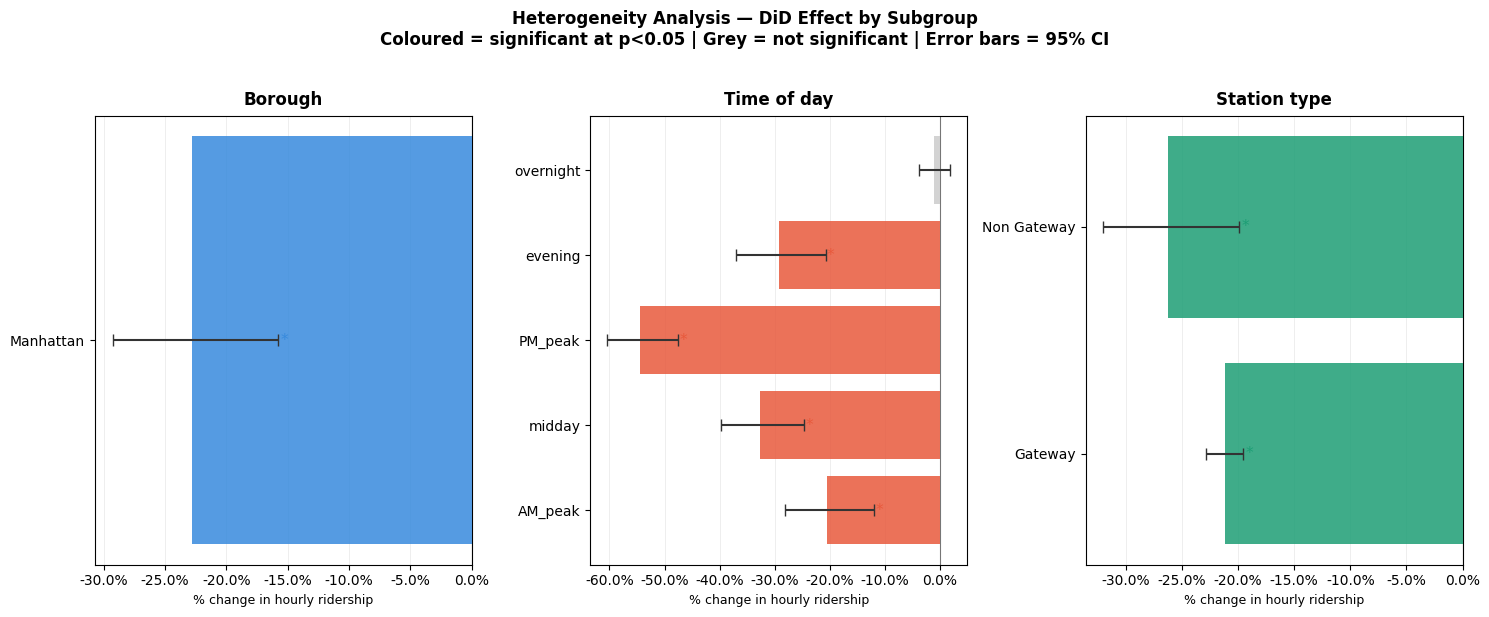

  Saved → /content/drive/MyDrive/MTA/clean_data/heterogeneity_summary_plot.png

  ✅  Section 8 complete.


In [ ]:
section('8 · COMBINED HETEROGENEITY PLOT')

plot_rows = []

# Borough results — only add if Model I ran
if 'borough_df' in dir() and len(borough_df) > 0:
    for _, row in borough_df.iterrows():
        plot_rows.append({
            'group'  : 'Borough',
            'label'  : row['borough'],
            'pct'    : row['pct_change'],
            'pct_lo' : row['pct_ci_low'],
            'pct_hi' : row['pct_ci_high'],
            'pval'   : row['pval'],
        })
else:
    print('  ⚠️   borough_df not found — run Section 6 (Model I) first.')

# Time-of-day results — only add if Model J ran
if 'tod_df' in dir() and len(tod_df) > 0:
    for _, row in tod_df.iterrows():
        plot_rows.append({
            'group'  : 'Time of day',
            'label'  : row['time_of_day'],
            'pct'    : row['pct_change'],
            'pct_lo' : row['pct_ci_low'],
            'pct_hi' : row['pct_ci_high'],
            'pval'   : row['pval'],
        })
else:
    print('  ⚠️   tod_df not found — run Section 7 (Model J) first.')

# Gateway results — only add if Model G ran
if 'gateway_df' in dir() and len(gateway_df) > 0:
    for _, row in gateway_df.iterrows():
        plot_rows.append({
            'group'  : 'Station type',
            'label'  : row['group'].replace('_',' ').title(),
            'pct'    : row['pct_change'],
            'pct_lo' : row['pct_ci_low'],
            'pct_hi' : row['pct_ci_high'],
            'pval'   : row['pval'],
        })
else:
    print('  ⚠️   gateway_df not found — run Section 4 (Model G) first.')

if len(plot_rows) == 0:
    print('  ❌  No results to plot. Run Sections 4, 6, and 7 first.')
else:
    plot_df = pd.DataFrame(plot_rows)
    groups  = plot_df['group'].unique()
    n_panels= len(groups)

    fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 6), sharey=False)
    if n_panels == 1:
        axes = [axes]

    GROUP_COLORS = {
        'Borough'     : '#378ADD',
        'Time of day' : '#E8593C',
        'Station type': '#1D9E75',
    }

    for ax, group in zip(axes, groups):
        sub        = plot_df[plot_df['group'] == group].reset_index(drop=True)
        color      = GROUP_COLORS.get(group, '#888888')
        colors_bar = [color if p < 0.05 else '#CCCCCC' for p in sub['pval']]

        ax.barh(sub['label'], sub['pct'], color=colors_bar, alpha=0.85, zorder=3)
        ax.errorbar(
            sub['pct'], sub['label'],
            xerr=[sub['pct'] - sub['pct_lo'], sub['pct_hi'] - sub['pct']],
            fmt='none', color='#333', elinewidth=1.5, capsize=4, zorder=4
        )
        ax.axvline(0, color='black', lw=0.8, alpha=0.5)
        ax.set_title(group, fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('% change in hourly ridership', fontsize=9)
        ax.grid(axis='x', alpha=0.3, lw=0.5)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

        for i, (_, row) in enumerate(sub.iterrows()):
            if row['pval'] < 0.05:
                ax.text(row['pct_hi'] + 0.2, i, '*', va='center',
                        fontsize=11, color=color)

    fig.suptitle(
        'Heterogeneity Analysis — DiD Effect by Subgroup\n'
        'Coloured = significant at p<0.05 | Grey = not significant | Error bars = 95% CI',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUT_HETERO_PNG, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {OUT_HETERO_PNG}')

print('\n  ✅  Section 8 complete.')

In [ ]:
section('9 · EXPORT ALL RESULTS + SUMMARY TABLE')

all_results = []

# Model E — car ownership moderation
if 'coef_did' in dir() and 'coef_inter' in dir():
    all_results.append({
        'model': 'E', 'subgroup_type': 'Car ownership moderation',
        'label': 'did_term (at mean car own)',
        'coef': coef_did, 'pval': pval_did,
        'pct_change': pct_did,
        'pct_ci_low':  (np.exp(ci_did['lower']) - 1) * 100,
        'pct_ci_high': (np.exp(ci_did['upper']) - 1) * 100,
        'interaction_coef': coef_inter if not np.isnan(coef_inter) else np.nan,
        'interaction_pval': pval_inter if not np.isnan(pval_inter) else np.nan,
    })
else:
    print('  ⚠️   Model E results not found — skipping.')

# Model F — distance moderation
if 'coef_did_f' in dir() and 'coef_inter_f' in dir():
    all_results.append({
        'model': 'F', 'subgroup_type': 'Distance moderation',
        'label': 'did_term (at mean distance)',
        'coef': coef_did_f, 'pval': pval_did_f,
        'pct_change': pct_did_f,
        'pct_ci_low':  (np.exp(ci_did_f['lower']) - 1) * 100,
        'pct_ci_high': (np.exp(ci_did_f['upper']) - 1) * 100,
        'interaction_coef': coef_inter_f,
        'interaction_pval': pval_inter_f,
    })
else:
    print('  ⚠️   Model F results not found — skipping.')

# Model G — gateway
if 'gateway_df' in dir() and len(gateway_df) > 0:
    for _, row in gateway_df.iterrows():
        all_results.append({
            'model': 'G', 'subgroup_type': 'Gateway',
            'label': row['label'], 'coef': row['coef'], 'pval': row['pval'],
            'pct_change': row['pct_change'],
            'pct_ci_low': row['pct_ci_low'], 'pct_ci_high': row['pct_ci_high'],
            'interaction_coef': np.nan, 'interaction_pval': np.nan,
        })
else:
    print('  ⚠️   gateway_df not found — run Section 4 (Model G) first.')

# Model H — fare class
if 'fare_df' in dir() and len(fare_df) > 0:
    for _, row in fare_df.iterrows():
        all_results.append({
            'model': 'H', 'subgroup_type': 'Fare class',
            'label': row.get('fare_group', row['label']),
            'coef': row['coef'], 'pval': row['pval'],
            'pct_change': row['pct_change'],
            'pct_ci_low': row['pct_ci_low'], 'pct_ci_high': row['pct_ci_high'],
            'interaction_coef': np.nan, 'interaction_pval': np.nan,
        })
else:
    print('  ⚠️   fare_df not found — Section 5 (Model H) may have been skipped.')

# Model I — borough
if 'borough_df' in dir() and len(borough_df) > 0:
    for _, row in borough_df.iterrows():
        all_results.append({
            'model': 'I', 'subgroup_type': 'Borough',
            'label': row['borough'], 'coef': row['coef'], 'pval': row['pval'],
            'pct_change': row['pct_change'],
            'pct_ci_low': row['pct_ci_low'], 'pct_ci_high': row['pct_ci_high'],
            'interaction_coef': np.nan, 'interaction_pval': np.nan,
        })
else:
    print('  ⚠️   borough_df not found — run Section 6 (Model I) first.')

# Model J — time-of-day
if 'tod_df' in dir() and len(tod_df) > 0:
    for _, row in tod_df.iterrows():
        all_results.append({
            'model': 'J', 'subgroup_type': 'Time of day',
            'label': row['time_of_day'], 'coef': row['coef'], 'pval': row['pval'],
            'pct_change': row['pct_change'],
            'pct_ci_low': row['pct_ci_low'], 'pct_ci_high': row['pct_ci_high'],
            'interaction_coef': np.nan, 'interaction_pval': np.nan,
        })
else:
    print('  ⚠️   tod_df not found — run Section 7 (Model J) first.')

if len(all_results) == 0:
    print('  ❌  No results to export. Run at least one model section first.')
else:
    results_df = pd.DataFrame(all_results)
    results_df.to_csv(OUT_HETERO_CSV, index=False)

    print('  ┌──────────────────────────────────────────────────────────────────┐')
    print('  │  HETEROGENEITY RESULTS SUMMARY                                  │')
    print('  ├────────┬──────────────────────────────────┬──────────┬───────────┤')
    print('  │ Model  │ Subgroup                         │   pct    │  p-val    │')
    print('  ├────────┼──────────────────────────────────┼──────────┼───────────┤')
    for _, row in results_df.iterrows():
        sig = '*' if row['pval'] < 0.05 else ' '
        lbl = str(row['label'])[:32]
        print(f"  │ {row['model']:<6} │ {lbl:<32} │ {row['pct_change']:+.2f}%  │ {row['pval']:.4f} {sig}  │")
    print('  └────────┴──────────────────────────────────┴──────────┴───────────┘')
    print('  * = significant at p<0.05')

    print(f'\n  Saved → {OUT_HETERO_CSV}')
    size = os.path.getsize(OUT_HETERO_CSV) / 1024
    print(f'  File size : {size:.1f} KB')

print('''
  ─────────────────────────────────────────────────────────────────
  OUTPUTS PRODUCED
  ─────────────────────────────────────────────────────────────────
  mta_crz_heterogeneity_results.csv   → full results table
  heterogeneity_summary_plot.png      → combined panel plot
  ─────────────────────────────────────────────────────────────────
  NEXT STEP → Monte Carlo Simulation
  ─────────────────────────────────────────────────────────────────
  Use Model B did_term coefficient + 95% CI as inputs.
  Monte Carlo generates station-level uncertainty intervals
  — the core visual on the dashboard station map page.
  ─────────────────────────────────────────────────────────────────
''')

print('\n  ✅  Section 9 complete.')


  9 · EXPORT ALL RESULTS + SUMMARY TABLE
  ┌──────────────────────────────────────────────────────────────────┐
  │  HETEROGENEITY RESULTS SUMMARY                                  │
  ├────────┬──────────────────────────────────┬──────────┬───────────┤
  │ Model  │ Subgroup                         │   pct    │  p-val    │
  ├────────┼──────────────────────────────────┼──────────┼───────────┤
  │ E      │ did_term (at mean car own)       │ -18.61%  │ 0.0037 *  │
  │ F      │ did_term (at mean distance)      │ +27.53%  │ 0.3053    │
  │ G      │ Gateway stations (n=2)           │ -21.19%  │ 0.0000 *  │
  │ G      │ Non-gateway stations (n=425)     │ -26.20%  │ 0.0000 *  │
  │ H      │ Full fare                        │ -30.08%  │ 0.0000 *  │
  │ H      │ Reduced fare                     │ -1.68%  │ 0.0712    │
  │ I      │ Manhattan                        │ -22.82%  │ 0.0000 *  │
  │ J      │ AM_peak                          │ -20.47%  │ 0.0000 *  │
  │ J      │ midday                  